## HOW K-MEANS WORK:

#### The main objective of the K-Means algorithm is to minimize the sum of distances between the points and their respective cluster centroid.¶
1. Step 1: Choose the number of clusters k
2. Step 2: Select k random points from the data as centroids
3. Step 3: Assign all the points to the closest cluster centroid
4. Step 4: Recompute the centroids of newly formed clusters
5. Step 5: Repeat steps 3 and 4

---

### Full Explanation
K-Means Clustering algorithm, a popular unsupervised machine learning technique used to group similar data points into 'clusters'.

---

##### Problem Statement
To illustrate how K-Means works, consider a college placement cell that needs to group students based on two metrics: CGPA and IQ. While we can visually identify clusters in a 2D graph, K-Means is specifically designed for high-dimensional datasets where human visualization is impossible (01:10 - 03:10).

---

##### The Step-by-Step Algorithm
* Step 1: Decide the Number of Clusters (K)
    * Before starting, you must define the value of 'K', representing the total number of clusters you want to form.

* Step 2: Initializing Centroids
    * The algorithm randomly selects 'K' data points from the dataset to act as the initial centroids (the centers of the clusters).

* Step 3: Assigning Points to Clusters
    * This is the core of the algorithm. You calculate the Euclidean distance between every data point and each of the centroids.
    * Each point is assigned to the cluster whose centroid is nearest to it.

* Step 4: Updating Centroids
    * Once all points are assigned, you calculate the new centroid for each cluster by finding the mean of the CGPA and IQ values of all points within that specific cluster.

* Step 5: Iteration and Termination
    * You compare the positions of the new centroids with the previous ones.
    * If the centroids moved, return to Step 3 and repeat the assignment and update process.
    * If the centroids stop moving (i.e., they are at the same position as the previous iteration), the algorithm has converged, and the process is complete

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
iris_df = sns.load_dataset('iris')
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


<Axes: xlabel='sepal_length', ylabel='petal_length'>

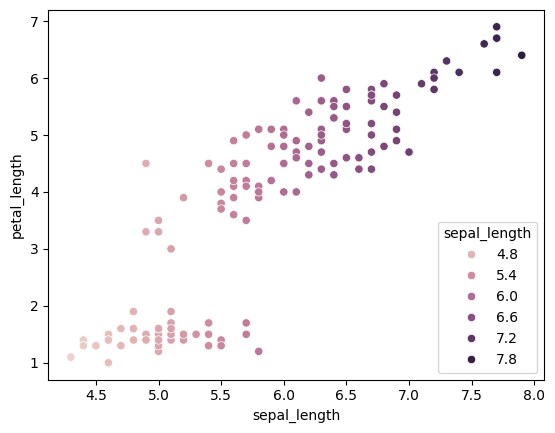

In [3]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_length', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='petal_width'>

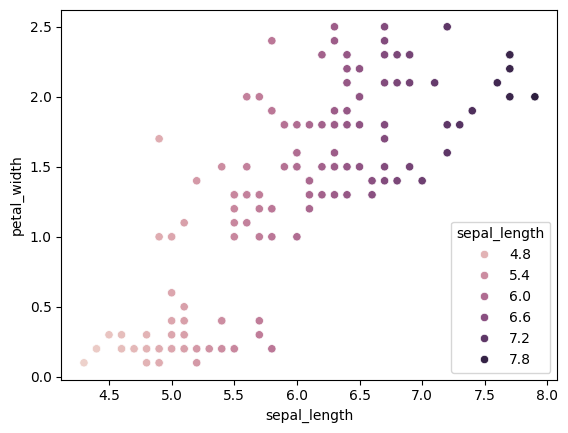

In [4]:
sns.scatterplot(data=iris_df, x='sepal_length', y='petal_width', hue='sepal_length')

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

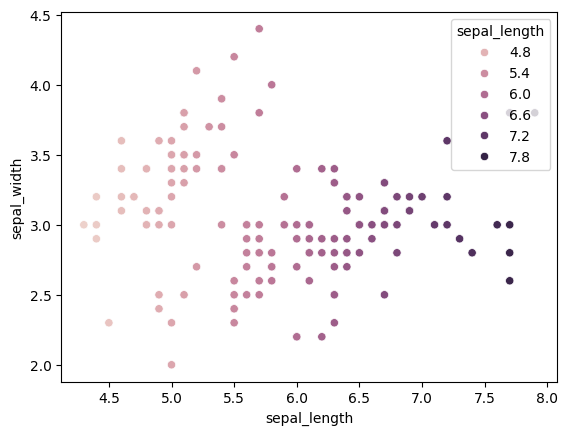

In [5]:
sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='sepal_length')

In [6]:
numeric_cols = iris_df.columns.tolist()
numeric_cols.remove('species')
numeric_cols

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [7]:
X_train = iris_df[numeric_cols]
X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# K-Means in Unsupervised Learning

K-Means is a **clustering algorithm** used in **unsupervised learning**.

Unsupervised means:

* No target variable (no labels).
* The algorithm finds patterns or structure in data by itself.

K-Means groups similar data points into **K clusters**.

---

## Main Idea

The goal is to:

> Divide data into K clusters such that points inside a cluster are similar, and clusters are different from each other.

Similarity is measured using **distance** (usually Euclidean distance).

---

# 📐 Mathematical Objective

K-Means minimizes:

$$
\sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2
$$


Where:
$$
(C_i) = cluster i
$$
$$
(\mu_i) = centroid of cluster i
$$
$$
(||x - \mu_i||^2) = squared distance
$$
This is called **Within-Cluster Sum of Squares (WCSS)**.

---

# Simple Example

Suppose you have height and weight data of people.

K-Means might group them as:

* Cluster 1 → Short & Light
* Cluster 2 → Medium
* Cluster 3 → Tall & Heavy

No labels were given — it discovered structure itself.

---

# Important Parameters (sklearn)

```python
from sklearn.cluster import KMeans

model = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
```

#### Key Parameters:

##### 1) n_clusters

* Number of clusters (K)
* Must be decided manually

---

##### 2) init

How centroids are initialized:

* 'k-means++' → Smart initialization (recommended)
* 'random' → Random selection

k-means++ improves convergence and stability.

---

##### 3) n_init

* Number of times algorithm runs with different centroid seeds.
* Best result is chosen.
* Higher = more stable but slower.

---

#### 4) max_iter

* Maximum iterations before stopping.

---

##### 5) random_state

* For reproducibility.

---

#### How to Choose K?

##### 1) Elbow Method

Plot WCSS vs K.

Look for a “bend” in the curve.

```python
inertia = []
for k in range(1, 10):
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)
```

Plot and observe elbow.

---

##### 2) Silhouette Score

Measures how well clusters are separated.

Range: -1 to 1
Closer to 1 = better clustering.

---

### ⚠️ Limitations of K-Means

1. You must choose K manually.
2. Works poorly with:

   * Non-spherical clusters
   * Different density clusters
3. Sensitive to outliers.
4. Assumes equal variance clusters.

---

### 🧠 Time Complexity

[
O(n \cdot k \cdot d \cdot i)
]

Where:

* n = number of samples
* k = clusters
* d = features
* i = iterations

---

### 🚀 When to Use K-Means?

Good for:

* Customer segmentation
* Image compression
* Market grouping
* Pattern discovery

Not good for:

* Complex shapes (use DBSCAN)
* Uneven density clusters

---

### 🔍 Difference from Supervised Learning

| Supervised                  | K-Means         |
| --------------------------- | --------------- |
| Has labels                  | No labels       |
| Predicts output             | Finds structure |
| Regression / Classification | Clustering      |

---


In [8]:
from sklearn.cluster import KMeans

In [9]:
# model = KMeans(
#     n_clusters=3,
#     init='k-means++',
#     n_init=10,
#     max_iter=300,
#     random_state=42
# )
model = KMeans(n_clusters=3,
               random_state=54)

In [10]:
model.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",54
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
model.cluster_centers_

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [12]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [13]:
preds = model.predict(X_train)
preds

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [ ]:
%%time
fig = px.scatter_3d(data_frame=iris_df, x=iris_df.sepal_length, y=iris_df.sepal_width, z=iris_df.petal_length, color=iris_df.petal_length)
fig.update_traces(marker = dict(size=2))
fig.update_layout(height = 700, width=700)
fig.show()

CPU times: total: 3.75 s
Wall time: 4.03 s
